# gMLP MPP — Local Test Run

Small model for quick local validation that the full pipeline works.
- Tiny embed_size (32), 1 gMLP layer
- Pre-collated batches (batch=32, repeat=2) — same pipeline as main training
- Few epochs
- Verifies: dataset → collator → pre-collation → model → trainer → metrics

In [1]:
import sys
from pathlib import Path

ROOT = Path(".").resolve()
if ROOT.name == "gMLP":
    ROOT = ROOT.parent.parent
elif ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import torch

if torch.cuda.is_available():
    device = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print("Device:", device)
print("ROOT:", ROOT)

Device: cpu
ROOT: D:\ML_skoltech\ML_project\ML_project-football-


## 1. Data & Vocab

In [2]:
from data.preprocessing import preprocess_raw_csv, build_vocab_mappings

raw_path = ROOT / "dataset" / "data_with_dates.csv"
sample_path = ROOT / "notebooks" / "train_sample_raw.csv"
output_dir = str(ROOT / "notebooks" / "train_sample_processed")

df_raw = pd.read_csv(raw_path)
df_raw.to_csv(sample_path, index=False)
df = preprocess_raw_csv(str(sample_path), output_dir)
vocab = build_vocab_mappings(df, output_dir)

print(f"Matches: {df['match_id'].nunique()}")
print(f"players_vocab_size (pad_idx): {vocab['player_pad_token_id']}")
print(f"MPP classes (real players): {vocab['player_pad_token_id'] - 1}")

Matches: 2923
players_vocab_size (pad_idx): 6394
MPP classes (real players): 6393


## 2. gMLP Dataset & Pre-collated Batches

In [3]:
from torch.utils.data import DataLoader
from data.dataset import MatchDatasetGMLP_MPP, PreCollatedDataset
from data.collator import DataCollatorMPP
try:
    from data.collator import DataCollatorPreCollated
except ImportError:
    from torch.utils.data.dataloader import default_collate
    class DataCollatorPreCollated:
        def __call__(self, batch):
            return default_collate(batch)

sample_batch_size = 32
repeat = 2
dev_ratio = 0.05
seed = 42

# ---- Split by match_id BEFORE creating batches (no data leakage) ----
match_ids = df["match_id"].unique()
np.random.seed(seed)
np.random.shuffle(match_ids)
dev_size = max(1, int(len(match_ids) * dev_ratio))
dev_match_ids = set(match_ids[:dev_size])
train_match_ids = set(match_ids[dev_size:])

df_train = df[df["match_id"].isin(train_match_ids)].reset_index(drop=True)
df_dev = df[df["match_id"].isin(dev_match_ids)].reset_index(drop=True)

print(f"Matches total: {len(match_ids)}, train: {len(train_match_ids)}, dev: {len(dev_match_ids)}")

# ---- Create separate datasets for train and dev ----
ds_train = MatchDatasetGMLP_MPP(
    df_train,
    player_name2id=vocab["player_name2id"],
    team_name2id=vocab["team_name2id"],
    player_pad_token_id=vocab["player_pad_token_id"],
    team_pad_token_id=vocab["team_pad_token_id"],
    position_pad_token_id=25,
)
ds_dev = MatchDatasetGMLP_MPP(
    df_dev,
    player_name2id=vocab["player_name2id"],
    team_name2id=vocab["team_name2id"],
    player_pad_token_id=vocab["player_pad_token_id"],
    team_pad_token_id=vocab["team_pad_token_id"],
    position_pad_token_id=25,
)

# Sanity check
sample = ds_train[0]
print(f"Seq length: {sample['input_ids'].shape[0]}")
print(f"Occupied slots: {sample['attention_mask'].sum().item()}")

collator = DataCollatorMPP(
    player_mask_token_id=vocab["player_mask_token_id"],
    mask_percentage=0.25,
)

def _collate_filter_none(batch):
    batch = [b for b in batch if b is not None]
    return collator(batch) if batch else None

# ---- Build train batches ----
loader_train = DataLoader(
    ds_train, batch_size=sample_batch_size, shuffle=True,
    collate_fn=_collate_filter_none, drop_last=True,
)
train_batches = []
for _ in range(repeat):
    for batch in loader_train:
        if batch is not None:
            train_batches.append(batch)

# ---- Build dev batches (drop_last=False to keep all dev matches) ----
loader_dev = DataLoader(
    ds_dev, batch_size=sample_batch_size, shuffle=True,
    collate_fn=_collate_filter_none, drop_last=False,
)
dev_batches = []
for _ in range(repeat):
    for batch in loader_dev:
        if batch is not None:
            dev_batches.append(batch)

train_dataset = PreCollatedDataset(train_batches)
eval_dataset = PreCollatedDataset(dev_batches)
collator_for_trainer = DataCollatorPreCollated()

print(f"Train batches: {len(train_batches)}, Dev batches: {len(dev_batches)}")

Matches total: 2923, train: 2777, dev: 146
Seq length: 50
Occupied slots: 22
Train batches: 172, Dev batches: 10


## 3. Tiny gMLP Model & Trainer

In [4]:
from models.gmlp.pretrain import gMLPMaskedPlayerModel
from training.trainer import build_training_args, build_trainer
from training.metrics import compute_metrics_mpp
from training.callbacks import BestNCheckpointCallback

# Tiny model for local testing
model = gMLPMaskedPlayerModel(
    embed_size=32,
    num_layers=1,
    d_ffn=128,
    dropout=0.05,
    form_stats_size=39,
    players_vocab_size=vocab["player_pad_token_id"],
    teams_vocab_size=vocab["team_pad_token_id"],
    use_teams_embeddings=False,
    seq_len=50,
)
model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
enc_params = sum(p.numel() for p in model.encoder.parameters())
print(f"Total params: {total_params:,}")
print(f"Encoder params: {enc_params:,}")

output_dir = str(ROOT / "notebooks" / "gMLP" / "test_output")
training_config = {
    "output_dir": output_dir,
    "num_train_epochs": 5,
    "per_device_train_batch_size": 1,
    "per_device_eval_batch_size": 1,
    "learning_rate": 1e-3,
    "weight_decay": 0.0,
    "warmup_ratio": 0.0,
    "lr_scheduler_type": "linear",
    "logging_steps": 20,
    "eval_strategy": "steps",
    "eval_steps": 20,
    "save_strategy": "no",
    "report_to": "none",
    "seed": seed,
}

best_ckpt_cb = BestNCheckpointCallback(
    metrics={"eval_loss": "min", "eval_accuracy_top3": "max"},
    top_n=2,
)

train_args = build_training_args(training_config)
trainer = build_trainer(
    model=model,
    args=train_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    compute_metrics=compute_metrics_mpp,
    data_collator=collator_for_trainer,
)
trainer.add_callback(best_ckpt_cb)
best_ckpt_cb.set_trainer(trainer)
print("Trainer ready.")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Total params: 425,935
Encoder params: 214,966
Trainer ready.


## 4. Train

In [5]:
trainer.train()
print("\n" + best_ckpt_cb.summary())

d:\ML_skoltech\ML_project\ML_project-football-\venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss,Validation Loss,Accuracy Top1,Accuracy Top3
20,8.804906,8.726934,0.003597,0.003597
40,8.674538,8.588616,0.004796,0.007794
60,8.527306,8.435105,0.004796,0.011391
80,8.360518,8.309420,0.006595,0.014988
100,8.222831,8.225855,0.010192,0.018585
120,8.164986,8.159030,0.010791,0.021583
140,8.094125,8.110811,0.011990,0.017986
160,8.075355,8.061193,0.011990,0.016787
180,7.965350,8.022875,0.011990,0.017386
200,7.832921,7.984352,0.011990,0.019185


  [BestN] eval_loss: updated top-2 (step 20, eval_loss=8.7269)
  [BestN] eval_accuracy_top3: updated top-2 (step 20, eval_accuracy_top3=0.0036)
  [BestN] eval_loss: updated top-2 (step 40, eval_loss=8.5886)
  [BestN] eval_accuracy_top3: updated top-2 (step 40, eval_accuracy_top3=0.0078)
  [BestN] eval_loss: updated top-2 (step 60, eval_loss=8.4351)
  [BestN] eval_accuracy_top3: updated top-2 (step 60, eval_accuracy_top3=0.0114)
  [BestN] eval_loss: updated top-2 (step 80, eval_loss=8.3094)
  [BestN] eval_accuracy_top3: updated top-2 (step 80, eval_accuracy_top3=0.0150)
  [BestN] eval_loss: updated top-2 (step 100, eval_loss=8.2259)
  [BestN] eval_accuracy_top3: updated top-2 (step 100, eval_accuracy_top3=0.0186)
  [BestN] eval_loss: updated top-2 (step 120, eval_loss=8.1590)
  [BestN] eval_accuracy_top3: updated top-2 (step 120, eval_accuracy_top3=0.0216)
  [BestN] eval_loss: updated top-2 (step 140, eval_loss=8.1108)
  [BestN] eval_loss: updated top-2 (step 160, eval_loss=8.0612)
  [B

## 5. Evaluate

In [8]:
from transformers.utils.notebook import NotebookProgressCallback
trainer.remove_callback(NotebookProgressCallback)
results = trainer.evaluate()
print("Eval results:")
for k, v in results.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

d:\ML_skoltech\ML_project\ML_project-football-\venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Eval results:
  eval_loss: 7.4971
  eval_accuracy_top1: 0.0162
  eval_accuracy_top3: 0.0264
  eval_runtime: 1.6970
  eval_samples_per_second: 5.8930
  eval_steps_per_second: 5.8930
  epoch: 5.0000


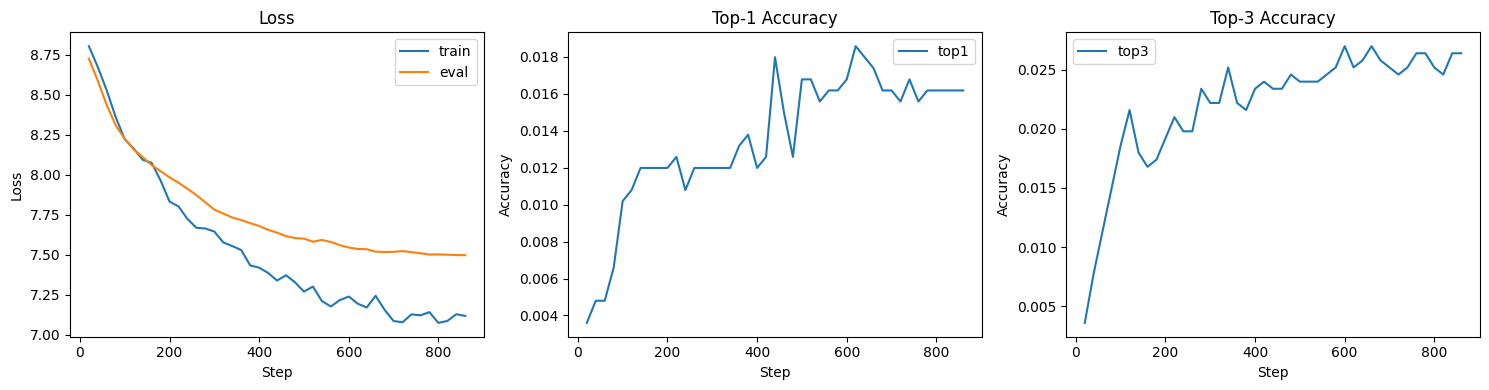

In [9]:
# Plot training loss from log history
import matplotlib.pyplot as plt

history = pd.DataFrame(trainer.state.log_history)
train_logs = history[history["loss"].notna()]
eval_logs = history[history["eval_loss"].notna()]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(train_logs["step"], train_logs["loss"], label="train")
if len(eval_logs) > 0:
    axes[0].plot(eval_logs["step"], eval_logs["eval_loss"], label="eval")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss")
axes[0].legend()

if "eval_accuracy_top1" in eval_logs.columns:
    axes[1].plot(eval_logs["step"], eval_logs["eval_accuracy_top1"], label="top1")
    axes[1].set_xlabel("Step")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_title("Top-1 Accuracy")
    axes[1].legend()

if "eval_accuracy_top3" in eval_logs.columns:
    axes[2].plot(eval_logs["step"], eval_logs["eval_accuracy_top3"], label="top3")
    axes[2].set_xlabel("Step")
    axes[2].set_ylabel("Accuracy")
    axes[2].set_title("Top-3 Accuracy")
    axes[2].legend()

plt.tight_layout()
plt.show()